# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: ZhouHongCheng



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

Import libraries for project at first code line. This allows the subsequent code to directly call the methods from libraries

# 1. Business Understanding
Goal: create regression model to evaluate house prices according to influential features (flat type, floor area)

# 2. Data Understanding

## 2.1 Load dataset

In [30]:
## Read *.csv file into pandas DataFrame
FILE_PATH = r"dataset.csv"
df = pd.read_csv(FILE_PATH)
df ## Display dataframe

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price
0,2000-01,BUKIT TIMAH,3 ROOM,8,EMPRESS RD,13 TO 15,76,Improved,1976,175000
1,2000-01,BUKIT TIMAH,3 ROOM,4,QUEEN'S RD,01 TO 03,74,Improved,1974,155000
2,2000-01,BUKIT TIMAH,3 ROOM,4,QUEEN'S RD,04 TO 06,73,Improved,1974,228000
3,2000-01,BUKIT TIMAH,4 ROOM,5,TOH YI DR,01 TO 03,104,Model A,1989,352800
4,2000-01,BUKIT TIMAH,5 ROOM,5,TOH YI DR,04 TO 06,128,Improved,1989,445000
...,...,...,...,...,...,...,...,...,...,...
933,2012-01,BUKIT TIMAH,3 ROOM,8,EMPRESS RD,04 TO 06,65,Improved,1976,427000
934,2012-01,BUKIT TIMAH,4 ROOM,4,TOH YI DR,10 TO 12,104,Model A,1988,605000
935,2012-01,BUKIT TIMAH,5 ROOM,16,TOH YI DR,01 TO 03,122,Improved,1988,658000
936,2012-02,BUKIT TIMAH,4 ROOM,16,TOH YI DR,07 TO 09,104,Model A,1988,588000


Read the data through pandas (pd.read_scv) and stroe data into variable name "df"  
Print out all data and perform a preliminary check on Column Name and Data Records

## 2.2 Summary Statistics

In [31]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 938 entries, 0 to 937
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   month                938 non-null    object
 1   town                 938 non-null    object
 2   flat_type            938 non-null    object
 3   block                938 non-null    int64 
 4   street_name          938 non-null    object
 5   storey_range         938 non-null    object
 6   floor_area_sqm       938 non-null    int64 
 7   flat_model           938 non-null    object
 8   lease_commence_date  938 non-null    int64 
 9   resale_price         938 non-null    int64 
dtypes: int64(4), object(6)
memory usage: 73.4+ KB


Understand all types of data
For object types -- I will use One-Hot Encoding to explore the relationship between the categorical features and the target variable
For numeric values (int64) -- I will use differnet plot, e.g. scatter, histagram, to explore the correlation with target variable

In [32]:
## Check for missing data
df.isna().sum() ## Alternative: df.isnull().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
resale_price           0
dtype: int64

Check empty values for each column. Because missing data may reduce the accuracy of the model and affect the reliability of the analysis

In [33]:
## Describe data distribution
df.describe(include="all")

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price
count,938,938,938,938.000000,938,938,938.000000,938,938.000000,938.000000
unique,145,1,4,NaN,4,8,NaN,7,NaN,NaN
top,2002-01,BUKIT TIMAH,4 ROOM,NaN,TOH YI DR,04 TO 06,NaN,Improved,NaN,NaN
freq,15,938,348,NaN,573,275,NaN,451,NaN,NaN
mean,NaN,NaN,NaN,7.594883,NaN,NaN,106.025586,NaN,1982.998934,384256.029851
std,NaN,NaN,NaN,4.986006,NaN,NaN,26.270479,NaN,6.777844,141264.383956
min,NaN,NaN,NaN,1.000000,NaN,NaN,63.000000,NaN,1974.000000,143000.000000
25%,NaN,NaN,NaN,4.000000,NaN,NaN,89.000000,NaN,1974.000000,290000.000000
50%,NaN,NaN,NaN,6.000000,NaN,NaN,104.000000,NaN,1988.000000,372250.000000
75%,NaN,NaN,NaN,11.000000,NaN,NaN,122.000000,NaN,1988.000000,465000.000000


Describe the distribution of numeric data. The result may be served as the basis for selecting the final model evaluation method. Since different real-world senarios and datasets require different evaluation methods

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

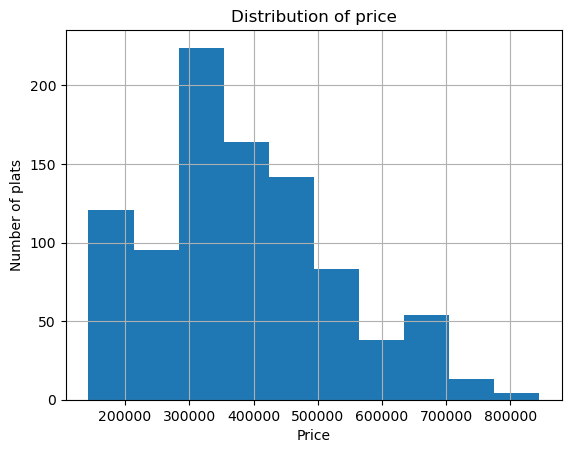

In [34]:
col_y = 'resale_price'

## Plot histogram
df[col_y].hist()
plt.title(f"Distribution of price")
plt.suptitle('')  # Remove default title by Pandas
plt.xlabel("Price")
plt.ylabel("Number of plats")
plt.show()

The histogram helsps visualize the distribution of target data more clearly. I analyze the distribution of the target variable to identify skewness and detect potential outliners before training the model

### 2.3.1.2 Understanding distribution of features

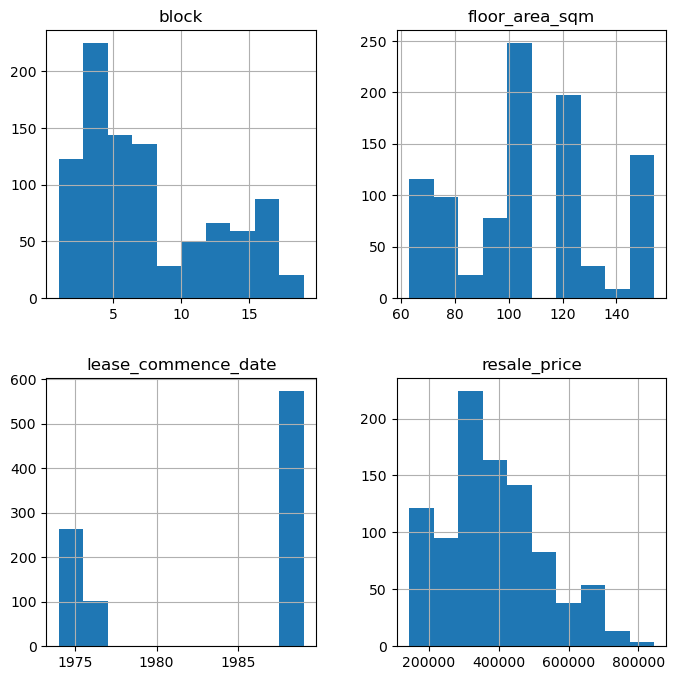

In [35]:
## Understanding distribution of features
df.hist(figsize=(8,8))
plt.show()

Visulaize the distribution of numerical features to identify data patterns, skewness, and potential outliers.
For taget column (resale_price), it is slighly right-skewed, indicating that higher-priced houses are less common
For floor_area_sqm, most properties fall within a moderate floor area range, while larger properties appear less frequently
For less_commence_date, most houses were built during a few specific periods, suggestion an uneven distribution of construction years

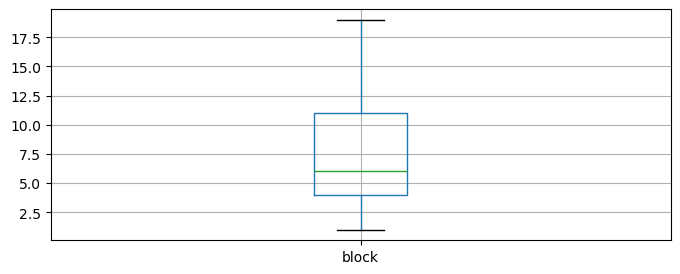

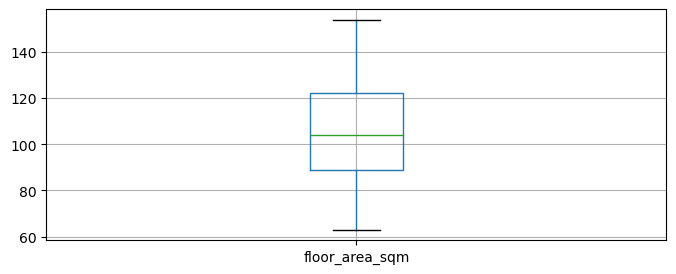

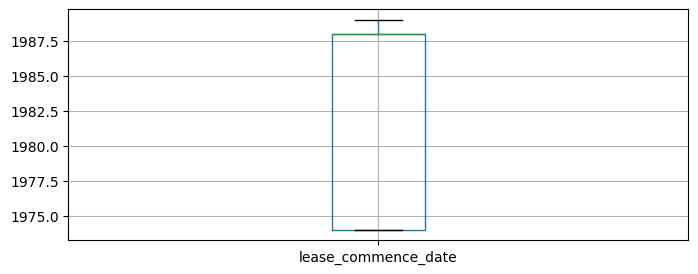

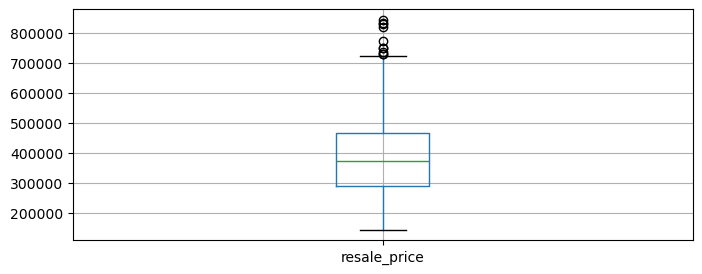

In [36]:
# analyze outliers

## retrieve numeric data columns
col_numeric = df.select_dtypes(include=['float', 'int']).columns ## Select all categorical columns

for col in col_numeric:
    df.boxplot(column=col, rot=0, figsize=(8,3))
    plt.show()

I create box plot for each of column. If they were put into the same plot, most of boxes were unable to expand and it is hard to analyze because their values span a wild value range.
The "block", "floor_area_sqm" and "lease_commence_date" show no obvious outliers. Their values fall within an reasonable range, indicating no additional outlier treatement is required
However, the box plot for "resale_price" contains several high-value outliers, they are retained because they likely represent valid property prices rather than incorrect data 

### 2.3.2 Understanding relationship between variables

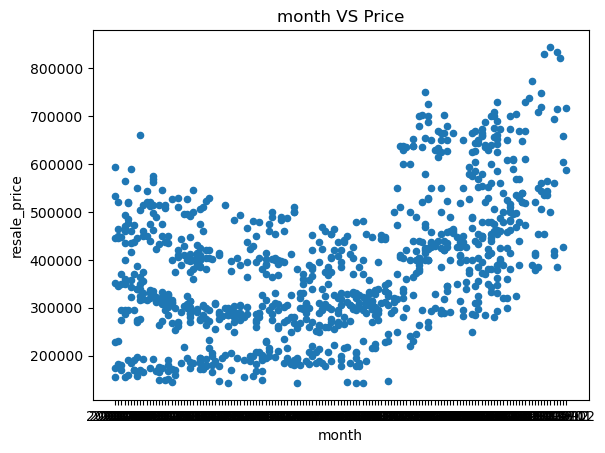

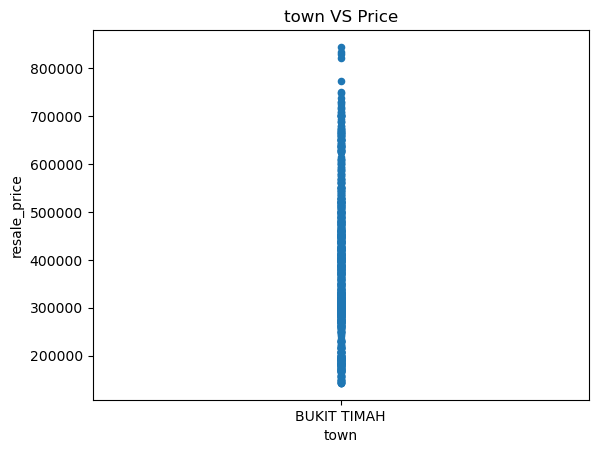

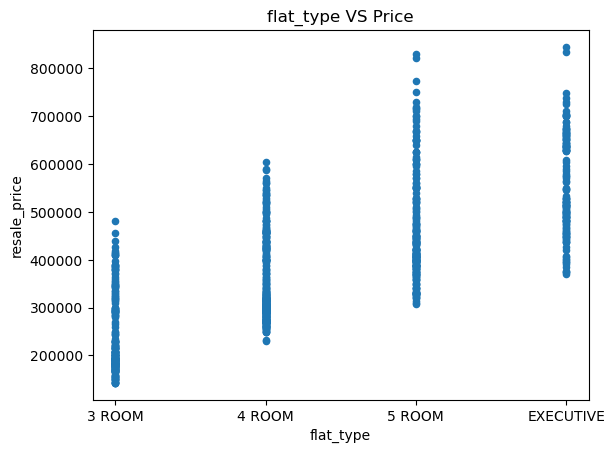

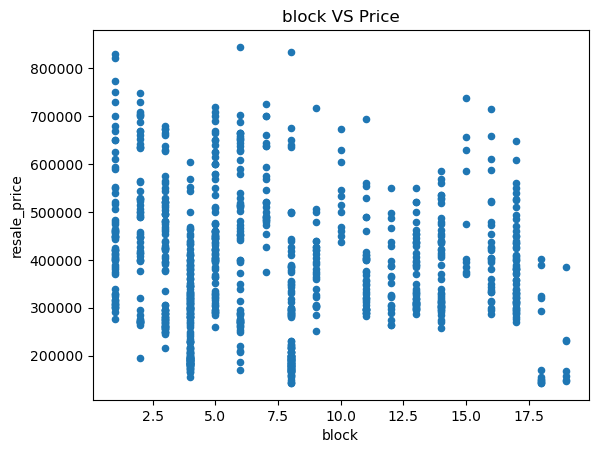

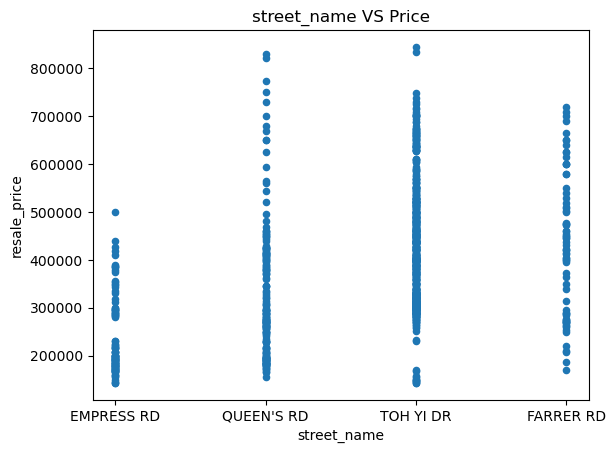

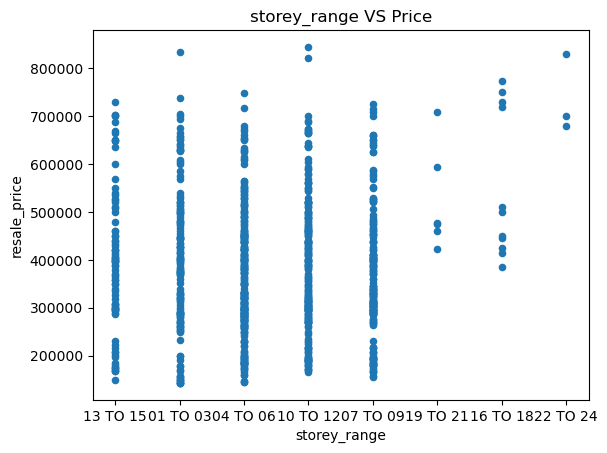

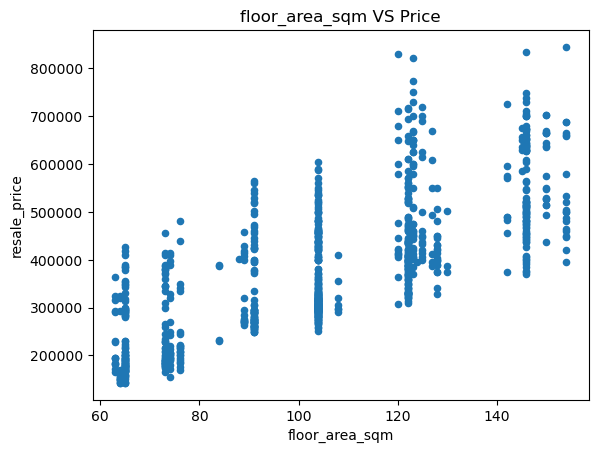

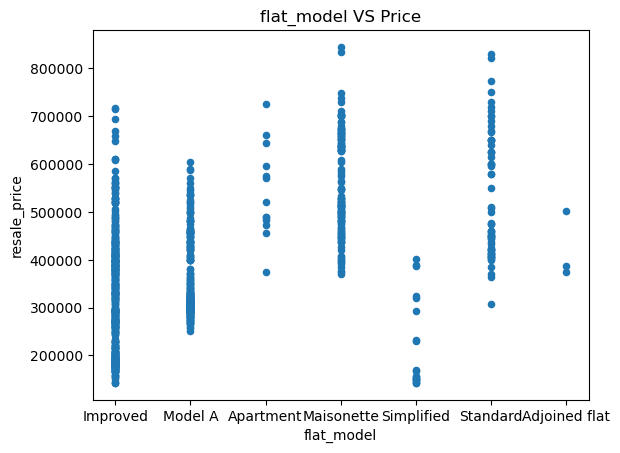

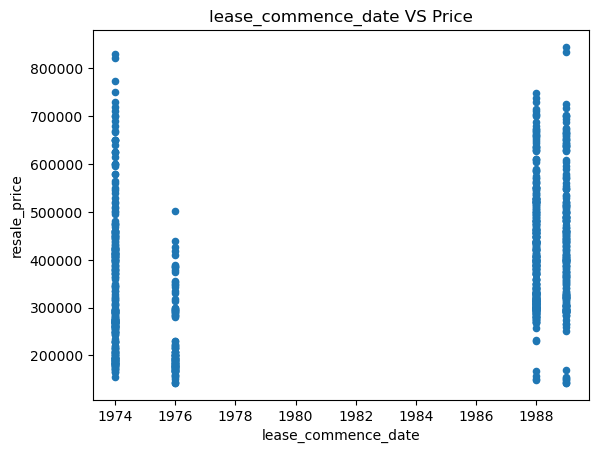

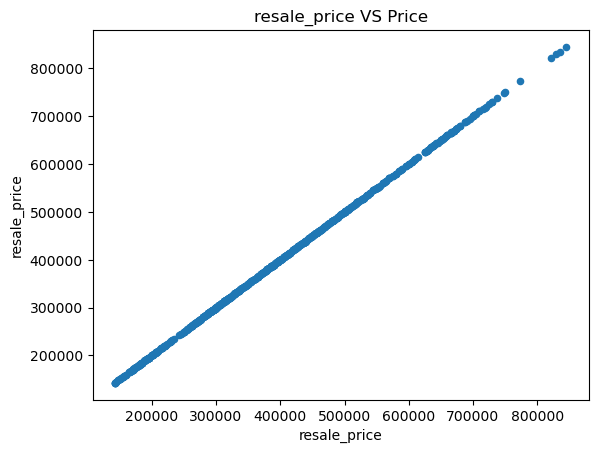

In [37]:
## Understanding relationship between variables
## Plot scatterplot
col_y = 'resale_price'

for col_x in df.columns:
    df.plot(x=col_x,
            y=col_y,
            kind='scatter')
    plt.title(f"{col_x} VS Price")
    plt.suptitle('')  # Remove default title by Pandas
    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.show()

In [38]:
df = df.drop("town", axis=1)

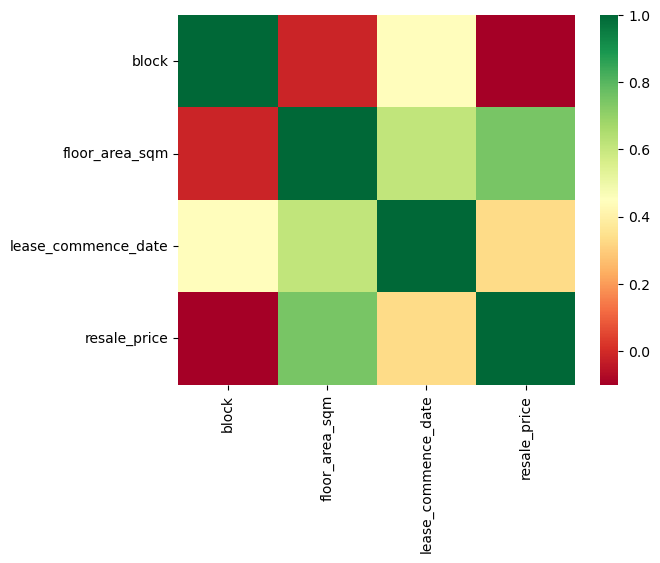

In [39]:
## Plot heatmap
## Display correlation matrix
df_corr = df[col_numeric].corr()
sns.heatmap(df_corr, cmap='RdYlGn')
plt.show()

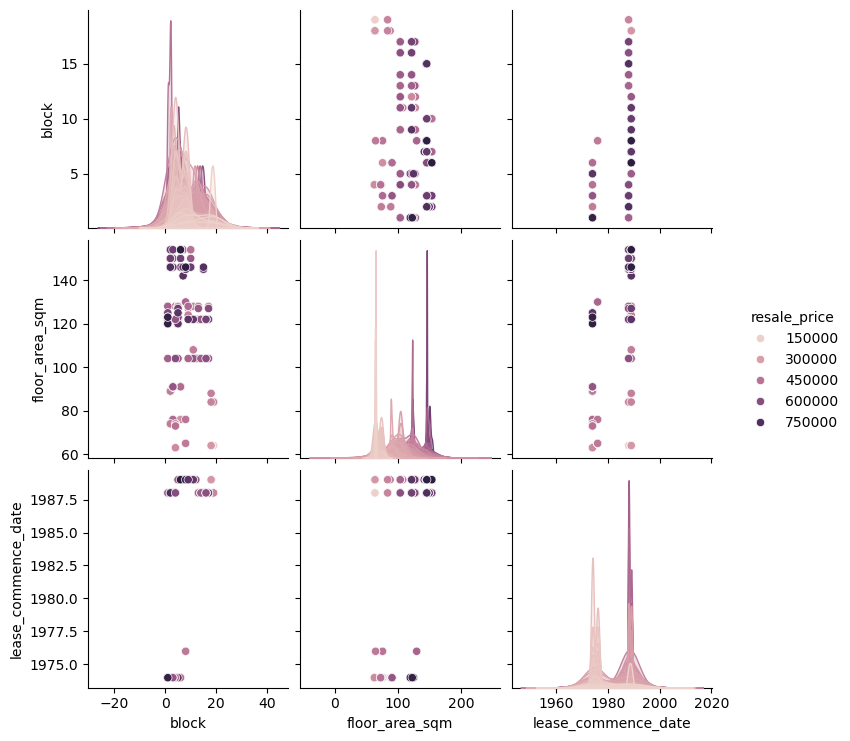

In [40]:
## Plot pairplot
sns.pairplot(df, hue=col_y)
plt.show()

# 3. Data Preparation

## 3.1 Data Cleaning

In [41]:
## Check datatypes for each column
df.dtypes

month                  object
flat_type              object
block                   int64
street_name            object
storey_range           object
floor_area_sqm          int64
flat_model             object
lease_commence_date     int64
resale_price            int64
dtype: object

In [42]:
## Check datatypes for each column
col_categorical = df.select_dtypes(include=['object']).columns ## Select all categorical columns

## Print data about categorical column
'''
nunique(): Return total number of unique values in column
unique(): Return unique values in column
'''
for col in df[col_categorical]:
    print(f'{col} ({df[col].nunique()}): {df[col].unique()}') 

month (145): ['2000-01' '2000-02' '2000-03' '2000-04' '2000-05' '2000-06' '2000-07'
 '2000-08' '2000-09' '2000-10' '2000-11' '2000-12' '2001-01' '2001-02'
 '2001-03' '2001-04' '2001-05' '2001-06' '2001-07' '2001-08' '2001-09'
 '2001-10' '2001-11' '2001-12' '2002-01' '2002-02' '2002-03' '2002-04'
 '2002-05' '2002-06' '2002-07' '2002-08' '2002-09' '2002-10' '2002-11'
 '2002-12' '2003-01' '2003-02' '2003-03' '2003-04' '2003-05' '2003-06'
 '2003-07' '2003-08' '2003-09' '2003-10' '2003-11' '2003-12' '2004-01'
 '2004-02' '2004-03' '2004-04' '2004-05' '2004-06' '2004-07' '2004-08'
 '2004-09' '2004-10' '2004-11' '2004-12' '2005-01' '2005-02' '2005-03'
 '2005-04' '2005-05' '2005-06' '2005-07' '2005-08' '2005-09' '2005-10'
 '2005-11' '2005-12' '2006-01' '2006-02' '2006-03' '2006-04' '2006-05'
 '2006-06' '2006-07' '2006-08' '2006-09' '2006-10' '2006-11' '2006-12'
 '2007-01' '2007-02' '2007-03' '2007-04' '2007-05' '2007-06' '2007-07'
 '2007-08' '2007-09' '2007-10' '2007-11' '2007-12' '2008-01' '20

In [43]:
## Split data into features (X) and target (y)
col_y = "resale_price"
y = df[col_y] ## Select target column 

col_irrelevant = [col_y, 'block', 
                  'floor_area_sqm',
                  'lease_commence_date']

X = df.drop(col_irrelevant, axis=1) ## Select feature columns 

## One-Hot Encoding
X = pd.get_dummies(X, 
               drop_first=True ## Remove redundant information
               )
X

,month_2000-02,month_2000-03,month_2000-04,month_2000-05,month_2000-06,month_2000-07,month_2000-08,month_2000-09,month_2000-10,month_2000-11,...,storey_range_13 TO 15,storey_range_16 TO 18,storey_range_19 TO 21,storey_range_22 TO 24,flat_model_Apartment,flat_model_Improved,flat_model_Maisonette,flat_model_Model A,flat_model_Simplified,flat_model_Standard
0,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
934,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
935,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
936,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


## 3.2 Train-Test Split

In [44]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split

## Split data into train set and test set
test_size = 0.3 
random_state = 2026 ## For reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=test_size, 
                                                    random_state=random_state)

# 4. Modelling

### 4.2 Train Model

In [45]:
## Initialise and train model
from sklearn.linear_model import LinearRegression
## Initialise model
model_linr = LinearRegression(fit_intercept=True) ## Linear Regression model
model_linr.fit(X_train, y_train) ## Train model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [46]:
## Initialise and train Random Forest model
from sklearn.ensemble import RandomForestRegressor
## Initialise model
model_rdn = RandomForestRegressor(random_state=random_state) ## Random Forest Regression model
model_rdn.fit(X_train, y_train) # Train Randem Forest Tree model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [47]:
## Initialise and train GradientBoosting model
from sklearn.ensemble import GradientBoostingRegressor
## Initialise model
model_gb = GradientBoostingRegressor(random_state=random_state) ## Random Forest Regression model
model_gb.fit(X_train, y_train) # Train Randem Forest Tree model

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

# 5. Model Evaluation

In [48]:
## Evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

## Evaluate model
y_pred_linr = model_linr.predict(X_test) ## Prediction using model 1

print("Linear Regression RMSE: ", root_mean_squared_error(y_test, y_pred_linr)) ## Calculate RMSE of model 1
print("Linear Regression R^2: ", r2_score(y_test, y_pred_linr)) ## Calculate R2 of model 1

Linear Regression RMSE:  43180.691436423425
Linear Regression R^2:  0.9088121806763885


In [49]:
## Evaluate additional model
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

## Evaluate model
y_pred_rdn = model_rdn.predict(X_test) ## Prediction using model 2

print("Random Forest Regression RMSE: ", root_mean_squared_error(y_test, y_pred_rdn)) ## Calculate RMSE of model 1
print("Random Forest Regression R^2: ", r2_score(y_test, y_pred_rdn)) ## Calculate R2 of model 1

Random Forest Regression RMSE:  85334.13995032625
Random Forest Regression R^2:  0.6438743318289959


In [54]:
## Evaluate additional model
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

## Evaluate model
y_pred_gb = model_gb.predict(X_test) ## Prediction using model 3

print("Gradient Boosting Regression RMSE: ", root_mean_squared_error(y_test, y_pred_gb)) ## Calculate RMSE of model 1
print("Gradient Boosting Regression R^2: ", r2_score(y_test, y_pred_gb)) ## Calculate R2 of model 1

Gradient Boosting Regression RMSE:  74326.07572782981
Gradient Boosting Regression R^2:  0.7298281774048048


In [51]:
## New data

## Predict


## Iterative model development


In [ ]:
## Further feature engineering / feature selection

